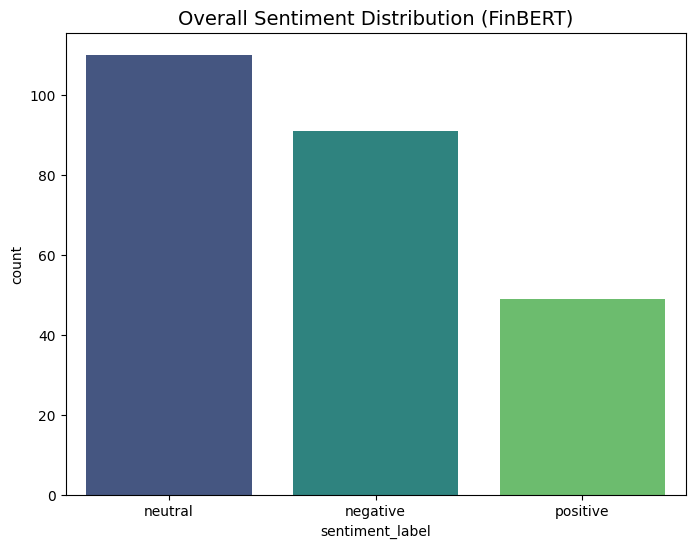

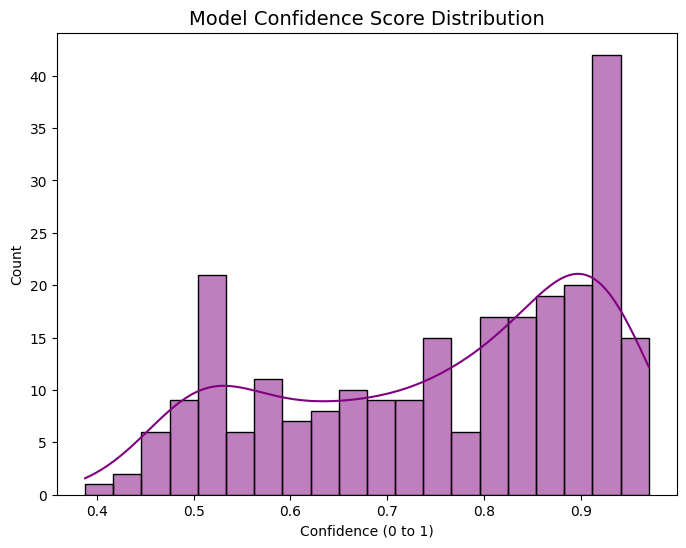

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv("../data/results/sentiment_results_v1.csv")

# 1. Overall Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sentiment_label', hue='sentiment_label', palette='viridis', legend=False)
plt.title("Overall Sentiment Distribution (FinBERT)", fontsize=14)
plt.show()

# 2. Confidence Score Analysis
# This tells us how "sure" the model is about its predictions
plt.figure(figsize=(8, 6))
sns.histplot(df['sentiment_score'], bins=20, kde=True, color='purple')
plt.title("Model Confidence Score Distribution", fontsize=14)
plt.xlabel("Confidence (0 to 1)")
plt.show()

In [4]:
# --- 1. REALITY CHECK ---
# Sampling 3 examples for each sentiment to audit the model
print("--- Sample Audit ---")
for sentiment in ['positive', 'negative', 'neutral']:
    print(f"\nTarget Sentiment: {sentiment.upper()}")
    sample = df[df['sentiment_label'] == sentiment].sample(min(3, len(df)))
    for i, row in sample.iterrows():
        print(f"- Title: {row['clean_title']}")
        print(f"  Confidence: {row['sentiment_score']:.4f}")

--- Sample Audit ---

Target Sentiment: POSITIVE
- Title: jobs report expected to show uptick in hiring as fed cuts interest rates
  Confidence: 0.7523
- Title: dow jones top markets headlines at 9 pm et  stocks advance as earnings boost markets  philly
  Confidence: 0.7768
- Title: some form of crisis is almost inevitable  the 38 trillion national debt will soon be growing faster than the u  s  economy itself  watchdog warns
  Confidence: 0.4873

Target Sentiment: NEGATIVE
- Title: the fed holds interest rates steady amid political scrutiny
  Confidence: 0.5120
- Title: eur  usd steadies near 1  1720 as trader shrugs off venezuela jitters
  Confidence: 0.6178
- Title: trump insists that federal reserve cut interest rates sharply  immediately
  Confidence: 0.8145

Target Sentiment: NEUTRAL
- Title: understanding forward guidance in monetary policy
  Confidence: 0.8698
- Title: why the federal reserve has been independent of the white house
  Confidence: 0.8982
- Title: the fed is heade

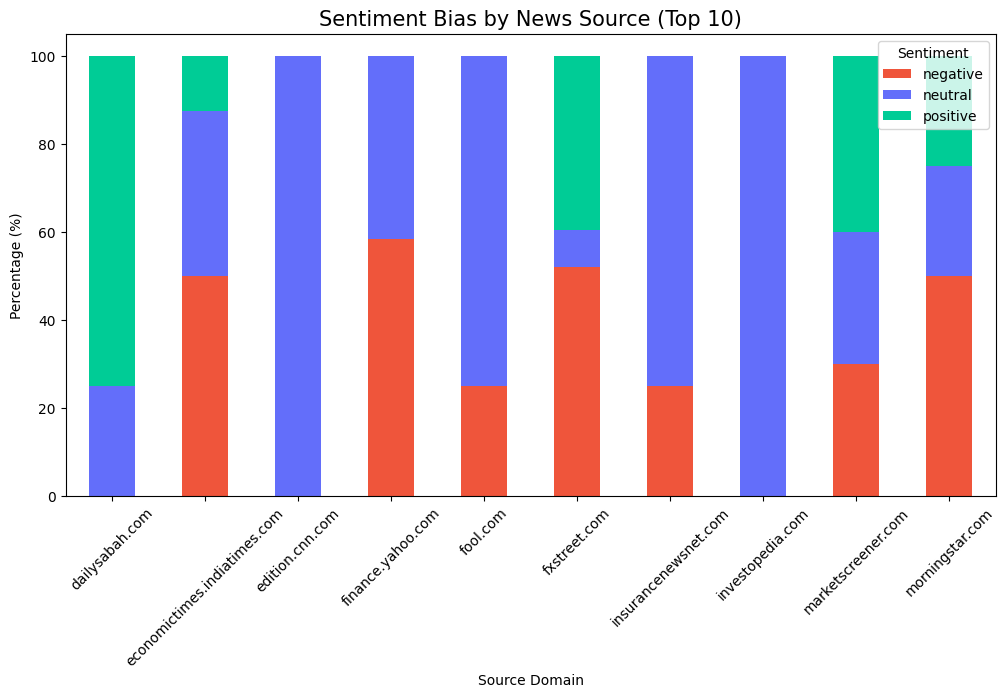

In [8]:
# --- 2. SOURCE BIAS ANALYSIS ---
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 10 sources to avoid cluttering the chart
top_10_sources = df['source_name'].value_counts().head(10).index
bias_df = df[df['source_name'].isin(top_10_sources)]

# Create a cross-tabulation of Source vs Sentiment
source_sentiment = pd.crosstab(bias_df['source_name'], bias_df['sentiment_label'], normalize='index') * 100

# Plotting
source_sentiment.plot(figsize=(12, 6), kind='bar', stacked=True, color=['#EF553B', '#636EFA', '#00CC96'])
plt.title("Sentiment Bias by News Source (Top 10)", fontsize=15)
plt.ylabel("Percentage (%)")
plt.xlabel("Source Domain")
plt.legend(title="Sentiment", loc='upper right')
plt.xticks(rotation=45)
plt.show()

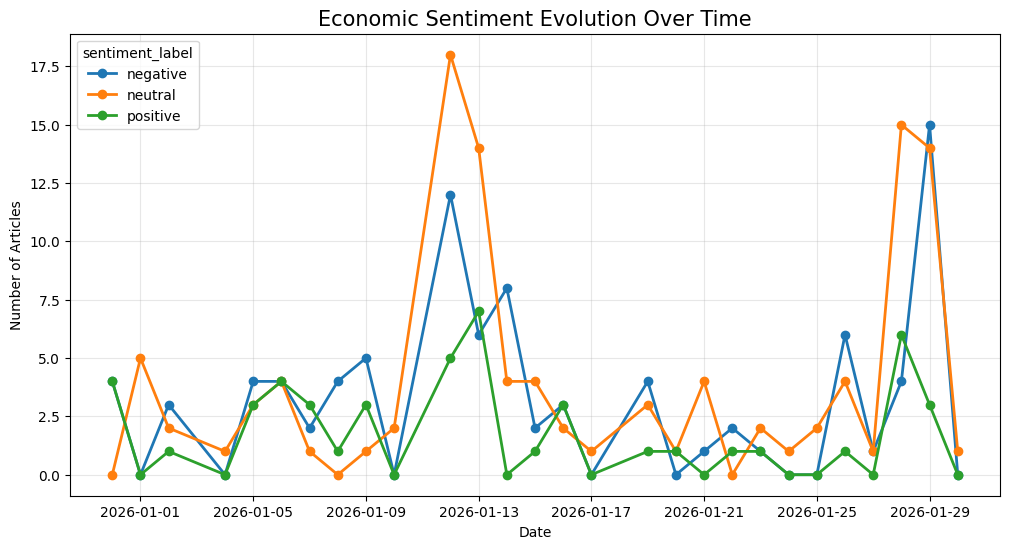

In [7]:
# --- 3. TEMPORAL CORRELATION ---

# Ensure datetime is in the right format (using the ISO8601 fix from before)
df['datetime'] = pd.to_datetime(df['seendate'], format='ISO8601')
df['date'] = df['datetime'].dt.date

# Group by date and sentiment
temporal_sentiment = df.groupby(['date', 'sentiment_label']).size().unstack(fill_value=0)

# Plotting the trend
temporal_sentiment.plot(figsize=(12, 6), marker='o', linewidth=2)
plt.title("Economic Sentiment Evolution Over Time", fontsize=15)
plt.ylabel("Number of Articles")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()